In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set()

# EDA — Dataset UCI Credit Card Default
**Aprendizaje de Máquina - CEIA - FIUBA**

*Notebook optativa*

Este dataset proviene de un banco de **Taiwán** y contiene el historial de **30.000 clientes de tarjeta de crédito**
entre abril y septiembre de 2005. El objetivo es predecir si el cliente va a **caer en default** (no pagar) el mes
siguiente.

Un detalle a tener en cuenta al leer los montos: están todos en **dólares taiwaneses (NT\$)**, cuya cotización ronda
los NT\$30 por dólar estadounidense. Un límite de crédito de NT\$140.000 equivale a unos USD 4.500.

## Variables

| Feature | Descripción | Unidad / codificación |
|---|---|---|
| `LIMIT_BAL` | Límite de crédito otorgado | NT\$ |
| `SEX` | Sexo | 1 = masculino, 2 = femenino |
| `EDUCATION` | Nivel educativo | 1 = posgrado, 2 = universidad, 3 = secundario, 4 = otros |
| `MARRIAGE` | Estado civil | 1 = casado/a, 2 = soltero/a, 3 = otros |
| `AGE` | Edad | años |
| `PAY_0` … `PAY_6` | Estado de pago en sept., ago., …, abril | −1 = pagó al día, 1 = un mes de atraso, 2 = dos meses, … |
| `BILL_AMT1` … `BILL_AMT6` | Monto del resumen de cuenta, sept. … abril | NT\$ |
| `PAY_AMT1` … `PAY_AMT6` | Monto efectivamente pagado, sept. … abril | NT\$ |
| `default.payment.next.month` | **Target**: cayó en default el mes siguiente | 0 = no, 1 = sí |

Notar que hay tres bloques de seis variables cada uno (`PAY_*`, `BILL_AMT*`, `PAY_AMT*`) que son **la misma medición
repetida mes a mes**, de septiembre hacia atrás.

In [2]:
df = pd.read_csv("data/UCI_Credit_Card.csv")

TARGET = "default.payment.next.month"

# Columna con etiquetas legibles para graficar
df["situacion"] = df[TARGET].map({0: "Al día", 1: "Default"})

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,situacion
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,Default
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,Default
2,3,90000.0,2,2,2,34,0,0,0,0,...,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,Al día
3,4,50000.0,2,2,1,37,0,0,0,0,...,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,Al día
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,Al día


In [3]:
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1] - 3} features + 1 target")
print(f"Valores nulos: {df.isna().sum().sum()}")
duplicadas = df.drop(columns=["ID", "situacion"]).duplicated().sum()
print(f"Filas duplicadas (sin contar ID): {duplicadas}")

Dimensiones: 30000 filas × 23 features + 1 target
Valores nulos: 0
Filas duplicadas (sin contar ID): 35


No hay valores nulos y las 35 filas duplicadas son despreciables sobre 30.000.

Que no haya nulos, sin embargo, **no significa que no haya problemas de calidad**. Vamos a encontrarlos más abajo.

---
## Tipos de variables

`pandas` lee todo el dataset como numérico, pero eso es un artefacto de cómo está codificado: varias columnas son en
realidad **categorías disfrazadas de números**. Confundirlas tiene consecuencias concretas al modelar, así que
conviene separarlas desde el principio.

In [4]:
df.drop(columns=["ID", "situacion"]).dtypes.value_counts()

float64    13
int64      11
Name: count, dtype: int64

In [5]:
# Cuántos valores distintos toma cada columna
n_unicos = df.drop(columns=["ID", "situacion", TARGET]).nunique().sort_values()
n_unicos

SEX              2
MARRIAGE         4
EDUCATION        7
PAY_5           10
PAY_6           10
PAY_0           11
PAY_2           11
PAY_3           11
PAY_4           11
AGE             56
LIMIT_BAL       81
PAY_AMT5      6897
PAY_AMT4      6937
PAY_AMT6      6939
PAY_AMT3      7518
PAY_AMT2      7899
PAY_AMT1      7943
BILL_AMT6    20604
BILL_AMT5    21010
BILL_AMT4    21548
BILL_AMT3    22026
BILL_AMT2    22346
BILL_AMT1    22723
dtype: int64

El conteo de valores únicos separa los dos grupos con bastante claridad: hay columnas con 2 a 11 valores distintos y
otras con miles.

Clasifiquemos las variables en tres tipos:

| Tipo | Variables | Por qué |
|---|---|---|
| **Categóricas nominales** | `SEX`, `EDUCATION`, `MARRIAGE` | Los números son etiquetas sin orden. Que `EDUCATION = 3` no es "más" que `EDUCATION = 1`. |
| **Categóricas ordinales** | `PAY_0` … `PAY_6` | Los números sí tienen orden (más atraso es peor), pero son categorías: pocos niveles y distancias no comparables. |
| **Numéricas continuas** | `LIMIT_BAL`, `AGE`, `BILL_AMT*`, `PAY_AMT*` | Magnitudes reales, donde la distancia entre valores tiene sentido. |

In [6]:
NOMINALES = ["SEX", "EDUCATION", "MARRIAGE"]
ORDINALES = ["PAY_0"] + [f"PAY_{i}" for i in range(2, 7)]
NUMERICAS = (["LIMIT_BAL", "AGE"]
             + [f"BILL_AMT{i}" for i in range(1, 7)]
             + [f"PAY_AMT{i}" for i in range(1, 7)])

print(f"Nominales: {len(NOMINALES)}  {NOMINALES}")
print(f"Ordinales: {len(ORDINALES)}  {ORDINALES}")
print(f"Numéricas: {len(NUMERICAS)}  {NUMERICAS}")
print(f"Total: {len(NOMINALES) + len(ORDINALES) + len(NUMERICAS)} features")

Nominales: 3  ['SEX', 'EDUCATION', 'MARRIAGE']
Ordinales: 6  ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Numéricas: 14  ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Total: 23 features


In [7]:
df[NUMERICAS].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.3,129747.7,10000.0,50000.0,140000.0,240000.0,1000000.0
AGE,30000.0,35.5,9.2,21.0,28.0,34.0,41.0,79.0
BILL_AMT1,30000.0,51223.3,73635.9,-165580.0,3558.8,22381.5,67091.0,964511.0
BILL_AMT2,30000.0,49179.1,71173.8,-69777.0,2984.8,21200.0,64006.2,983931.0
BILL_AMT3,30000.0,47013.2,69349.4,-157264.0,2666.2,20088.5,60164.8,1664089.0
BILL_AMT4,30000.0,43262.9,64332.9,-170000.0,2326.8,19052.0,54506.0,891586.0
BILL_AMT5,30000.0,40311.4,60797.2,-81334.0,1763.0,18104.5,50190.5,927171.0
BILL_AMT6,30000.0,38871.8,59554.1,-339603.0,1256.0,17071.0,49198.2,961664.0
PAY_AMT1,30000.0,5663.6,16563.3,0.0,1000.0,2100.0,5006.0,873552.0
PAY_AMT2,30000.0,5921.2,23040.9,0.0,833.0,2009.0,5000.0,1684259.0


Las variables numéricas tienen escalas radicalmente distintas: `AGE` va de 21 a 79, mientras que `BILL_AMT1` llega
a casi un millón de NT\$. Cualquier modelo basado en distancias o en regularización va a necesitar **escalado**.

Además, los montos están **muy sesgados a la derecha** (la media de `PAY_AMT1` es 5.664 pero el máximo supera los
870.000) y algunos `BILL_AMT*` tienen valores negativos, que corresponden a clientes con saldo a favor.

---
## Distribución de la variable objetivo

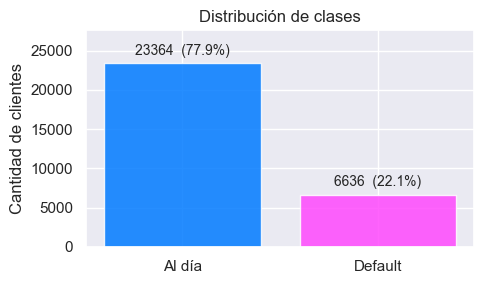

In [8]:
conteo = df["situacion"].value_counts()
colores_clase = {"Al día": "#007aff", "Default": "#ff48fd"}

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(conteo.index, conteo.values,
              color=[colores_clase[k] for k in conteo.index], alpha=0.85)
ax.bar_label(bars,
             labels=[f"{v}  ({v / len(df) * 100:.1f}%)" for v in conteo.values],
             padding=4, fontsize=10)
ax.set_ylabel("Cantidad de clientes")
ax.set_title("Distribución de clases")
ax.set_ylim(0, conteo.max() * 1.18)
plt.tight_layout()
plt.show()

El dataset está **desbalanceado**: solo el $22.1\%$ de los clientes cae en default.

La consecuencia práctica es que el **accuracy va a ser engañoso**: predecir "nunca hay default" ya acierta el
$77.9\%$ de las veces sin mirar un solo dato. Conviene apoyarse en $F_1$, exactitud balanceada o AUC.

---
## Variables categóricas nominales

Para una categórica, lo informativo no es su distribución sino **cómo cambia la tasa de default entre categorías**.

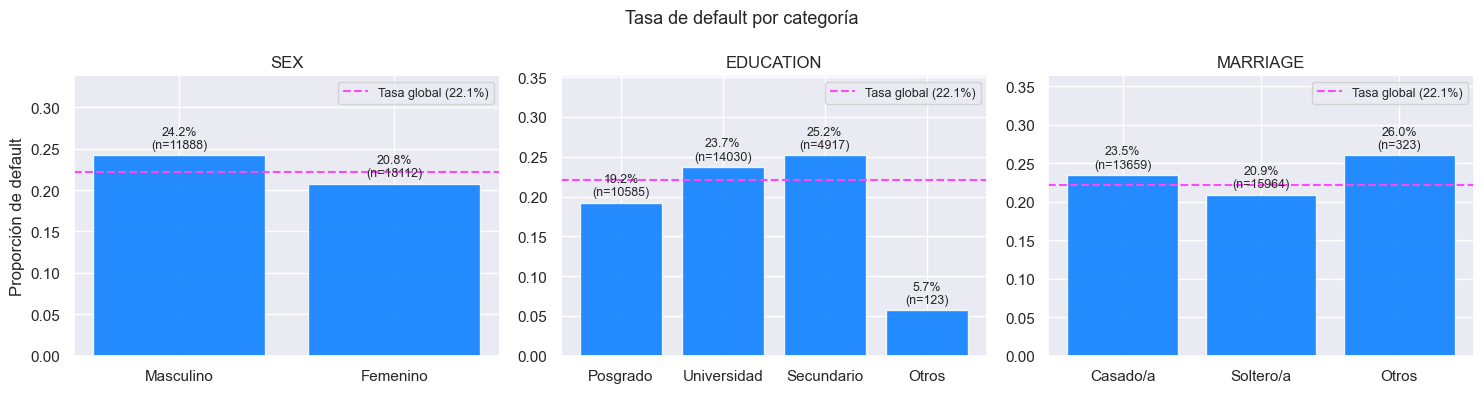

In [9]:
etiquetas = {
    "SEX": {1: "Masculino", 2: "Femenino"},
    "EDUCATION": {1: "Posgrado", 2: "Universidad", 3: "Secundario", 4: "Otros"},
    "MARRIAGE": {1: "Casado/a", 2: "Soltero/a", 3: "Otros"},
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
tasa_global = df[TARGET].mean()

for ax, (col, mapa) in zip(axes, etiquetas.items()):
    sub = df[df[col].isin(mapa)].copy()
    agg = sub.groupby(col).agg(tasa=(TARGET, "mean"), n=(TARGET, "size"))
    agg.index = [mapa[i] for i in agg.index]

    bars = ax.bar(agg.index, agg["tasa"], color="#007aff", alpha=0.85)
    ax.bar_label(bars, labels=[f"{t:.1%}\n(n={int(n)})" for t, n in
                               zip(agg["tasa"], agg["n"])], padding=3, fontsize=9)
    ax.axhline(tasa_global, color="#ff48fd", linestyle="--", lw=1.5,
               label="Tasa global (22.1%)")
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("Proporción de default" if ax is axes[0] else "")
    ax.set_ylim(0, agg["tasa"].max() * 1.4)
    ax.legend(fontsize=9)

plt.suptitle("Tasa de default por categoría", fontsize=13)
plt.tight_layout()
plt.show()

Las tres variables discriminan poco, pero no son inútiles:

- **`EDUCATION`** ordena el riesgo de forma creciente entre los tres niveles con volumen: posgrado $19.2\%$,
  universidad $23.7\%$, secundario $25.2\%$. La categoría "Otros" queda muy abajo ($5.7\%$), pero son apenas 123
  clientes, así que ese número no es confiable.
- **`SEX`** muestra una diferencia chica pero consistente: $24.2\%$ contra $20.8\%$.
- **`MARRIAGE`** apenas separa, con los tres niveles entre $20.9\%$ y $26.0\%$.

Ninguna se acerca a lo que vamos a ver en el historial de pagos.

---
## Variables categóricas ordinales: el historial de atrasos

Las `PAY_*` codifican cuántos meses de atraso arrastraba el cliente en cada mes. `PAY_0` corresponde a septiembre de
2005, el mes inmediatamente anterior al que queremos predecir.

In [10]:
tabla_pay = df.groupby("PAY_0").agg(
    clientes=(TARGET, "size"),
    tasa_default=(TARGET, "mean"),
).round(3)

tabla_pay

,clientes,tasa_default
PAY_0,,
-2,2759,0.132
-1,5686,0.168
0,14737,0.128
1,3688,0.339
2,2667,0.691
3,322,0.758
4,76,0.684
5,26,0.500
6,11,0.545


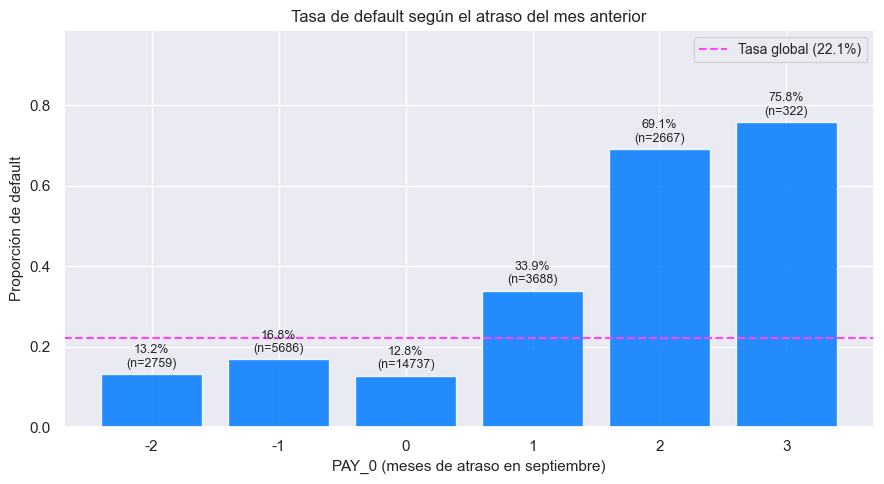

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

# Solo los valores con suficientes observaciones para ser confiables
sub = tabla_pay[tabla_pay["clientes"] >= 100]  # noqa: PLR2004

bars = ax.bar(sub.index.astype(str), sub["tasa_default"], color="#007aff", alpha=0.85)
ax.bar_label(bars, labels=[f"{v:.1%}\n(n={int(n)})" for v, n in
                           zip(sub["tasa_default"], sub["clientes"])],
             padding=3, fontsize=9)
ax.axhline(tasa_global, color="#ff48fd", linestyle="--", lw=1.5,
           label="Tasa global (22.1%)")

ax.set_xlabel("PAY_0 (meses de atraso en septiembre)", fontsize=11)
ax.set_ylabel("Proporción de default", fontsize=11)
ax.set_title("Tasa de default según el atraso del mes anterior", fontsize=12)
ax.set_ylim(0, sub["tasa_default"].max() * 1.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Acá está el predictor dominante del dataset. La tasa de default salta de **12.8%** para quienes estaban al día
(`PAY_0 = 0`) a **69.1%** para quienes ya arrastraban dos meses de atraso (`PAY_0 = 2`): un factor de más de cinco.

Hay dos observaciones importantes sobre la **forma** de esa relación:

- **No es lineal, es un escalón.** Entre `PAY_0 = -2`, `-1` y `0` la tasa es prácticamente la misma (entre $12.8\%$
  y $16.8\%$), y recién se dispara a partir de `1`. Un modelo que asuma que el riesgo crece de manera proporcional al
  número de meses de atraso va a ajustar mal esta forma. **Tratar a `PAY_0` como una variable numérica es una mala
  idea**; conviene codificarla como categoría.
- **Los valores `-2` y `0` no están documentados.** La descripción original del dataset solo define `-1` (pagó al
  día) y los enteros positivos. Por el comportamiento observado parecen corresponder a "sin consumo en el período" y
  "pago mínimo", pero es una interpretación.

Veamos si el resto de los meses aporta información propia o repite la misma señal.

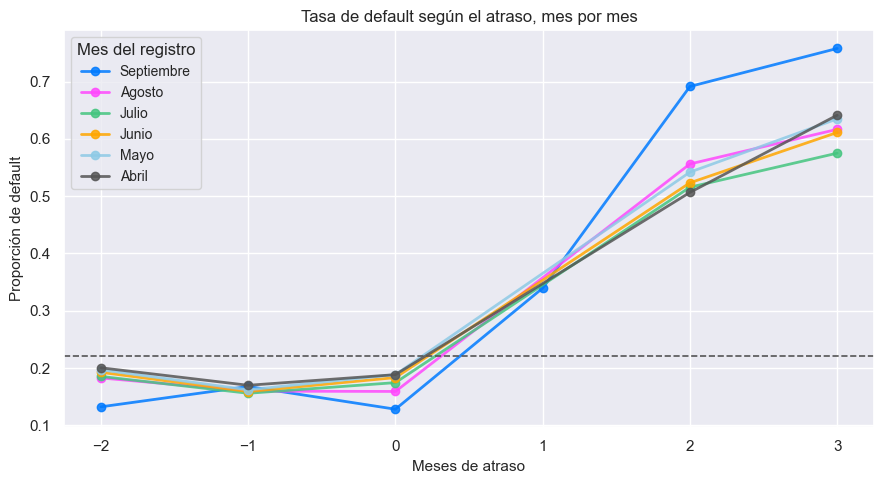

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
meses = {"PAY_0": "Septiembre", "PAY_2": "Agosto", "PAY_3": "Julio",
         "PAY_4": "Junio", "PAY_5": "Mayo", "PAY_6": "Abril"}
colores = ["#007aff", "#ff48fd", "#44c57f", "#ffa600", "#8ecae6", "#555555"]

for (col, mes), color in zip(meses.items(), colores):
    agg = df.groupby(col).agg(tasa=(TARGET, "mean"), n=(TARGET, "size"))
    agg = agg[(agg["n"] >= 100) & (agg.index <= 4)]  # noqa: PLR2004
    ax.plot(agg.index, agg["tasa"], "o-", lw=2, color=color, label=mes, alpha=0.85)

ax.axhline(tasa_global, color="#555555", linestyle="--", lw=1.2)
ax.set_xlabel("Meses de atraso", fontsize=11)
ax.set_ylabel("Proporción de default", fontsize=11)
ax.set_title("Tasa de default según el atraso, mes por mes", fontsize=12)
ax.legend(fontsize=10, title="Mes del registro")
plt.tight_layout()
plt.show()

Todos los meses muestran el mismo patrón, pero **cuanto más reciente es el mes, más pronunciada es la curva**.
Septiembre —el mes inmediatamente anterior— es el que mejor separa. Tiene sentido: un atraso de hace cinco meses
puede haberse regularizado.

---
## Variables numéricas

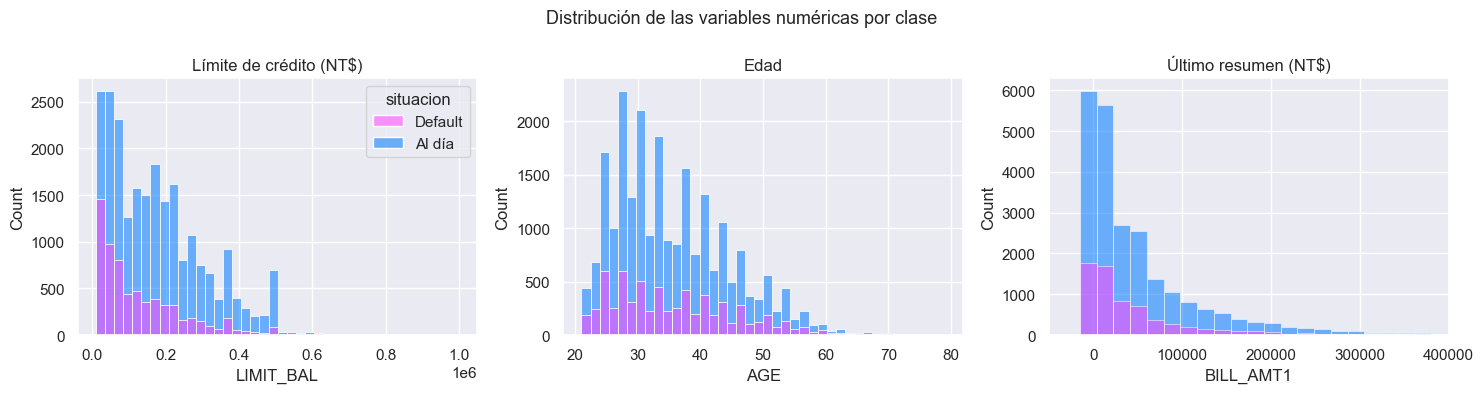

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=df, x="LIMIT_BAL", hue="situacion", palette=colores_clase,
             bins=40, alpha=0.55, ax=axes[0])
axes[0].set_title("Límite de crédito (NT$)")

sns.histplot(data=df, x="AGE", hue="situacion", palette=colores_clase,
             bins=40, alpha=0.55, ax=axes[1], legend=False)
axes[1].set_title("Edad")

sns.histplot(data=df, x="BILL_AMT1", hue="situacion", palette=colores_clase,
             bins=60, alpha=0.55, ax=axes[2], legend=False)
axes[2].set_title("Último resumen (NT$)")
axes[2].set_xlim(-50000, 400000)

plt.suptitle("Distribución de las variables numéricas por clase", fontsize=13)
plt.tight_layout()
plt.show()

El **límite de crédito** es la numérica más informativa: los defaults se concentran en los límites bajos. Es
razonable, porque el banco ya le asignó menos crédito a quien considera más riesgoso —la variable arrastra el juicio
previo del propio banco—.

La **edad** casi no discrimina y el **monto facturado** tampoco: las distribuciones de ambas clases están
prácticamente superpuestas.

---
## Problemas de calidad: categorías no documentadas

Aunque no haya nulos, `EDUCATION` y `MARRIAGE` tienen valores que no aparecen en el diccionario de datos.

In [14]:
for col, documentados in [("EDUCATION", [1, 2, 3, 4]), ("MARRIAGE", [1, 2, 3])]:
    conteo_col = df[col].value_counts().sort_index()
    fuera = conteo_col[~conteo_col.index.isin(documentados)]
    print(f"{col}: valores documentados {documentados}")
    print(f"  fuera del diccionario -> {dict(fuera)}  "
          f"({fuera.sum()} filas, {fuera.sum() / len(df):.2%})")
    print()

EDUCATION: valores documentados [1, 2, 3, 4]
  fuera del diccionario -> {0: np.int64(14), 5: np.int64(280), 6: np.int64(51)}  (345 filas, 1.15%)

MARRIAGE: valores documentados [1, 2, 3]
  fuera del diccionario -> {0: np.int64(54)}  (54 filas, 0.18%)



En `EDUCATION` aparecen los valores `0`, `5` y `6` (345 filas) y en `MARRIAGE` el valor `0` (54 filas). Juntos son
poco más del $1\%$ del dataset.

Son **datos ausentes o mal codificados que no se ven como faltantes**: `isna()` no los detecta. Lo habitual es
agruparlos dentro de la categoría "otros" que ya existe (`4` para educación, `3` para estado civil), que es lo que
haremos al armar el baseline.

---
## Correlación entre features

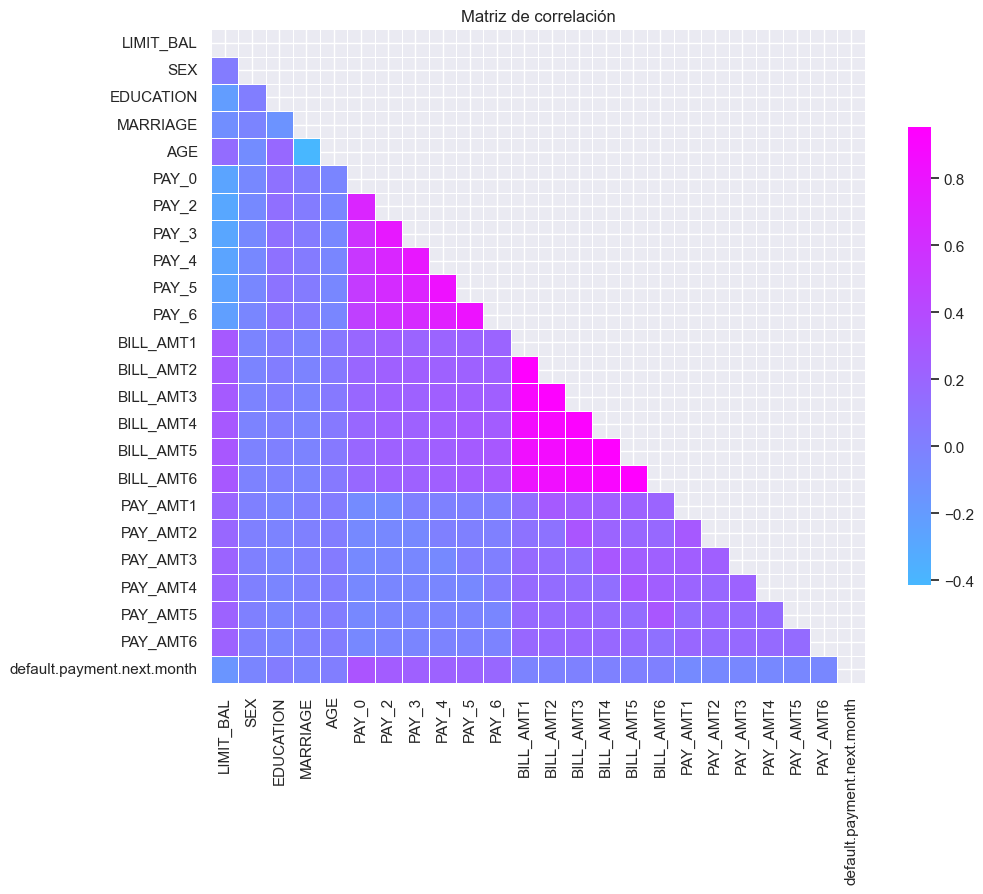

In [15]:
corr = df.drop(columns=["ID", "situacion"]).corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="cool", center=0, square=True,
            linewidths=0.4, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Matriz de correlación", fontsize=12)
plt.tight_layout()
plt.show()

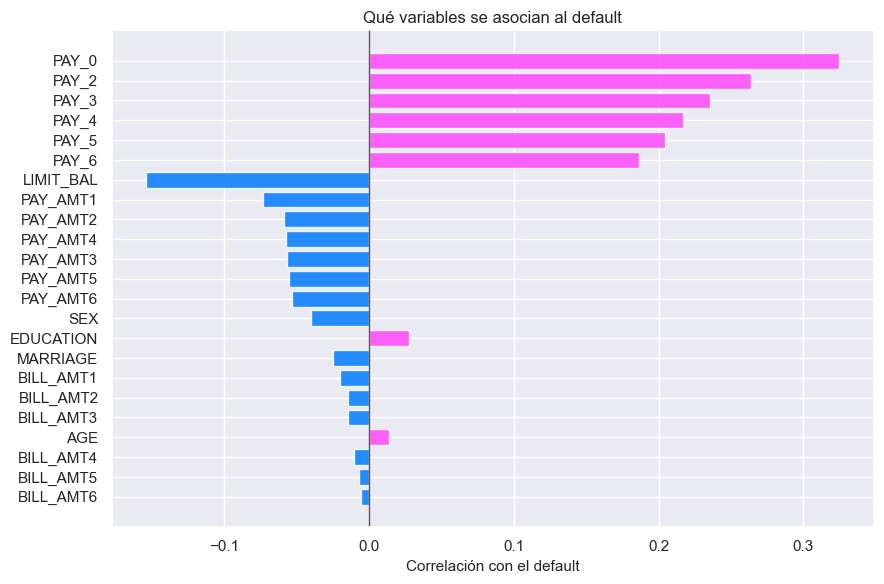

In [16]:
corr_target = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colores = ["#ff48fd" if v > 0 else "#007aff" for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1],
        color=colores[::-1], alpha=0.85)
ax.axvline(0, color="#555555", lw=1)
ax.set_xlabel("Correlación con el default", fontsize=11)
ax.set_title("Qué variables se asocian al default", fontsize=12)
plt.tight_layout()
plt.show()

Las seis `PAY_*` dominan por lejos, con `PAY_0` a la cabeza ($0.325$). `LIMIT_BAL` correlaciona negativamente
($-0.154$): más límite, menos riesgo. Los montos facturados casi no se asocian al default por sí solos.

En el mapa de calor se ven además tres bloques compactos. Miremos cada uno por separado.

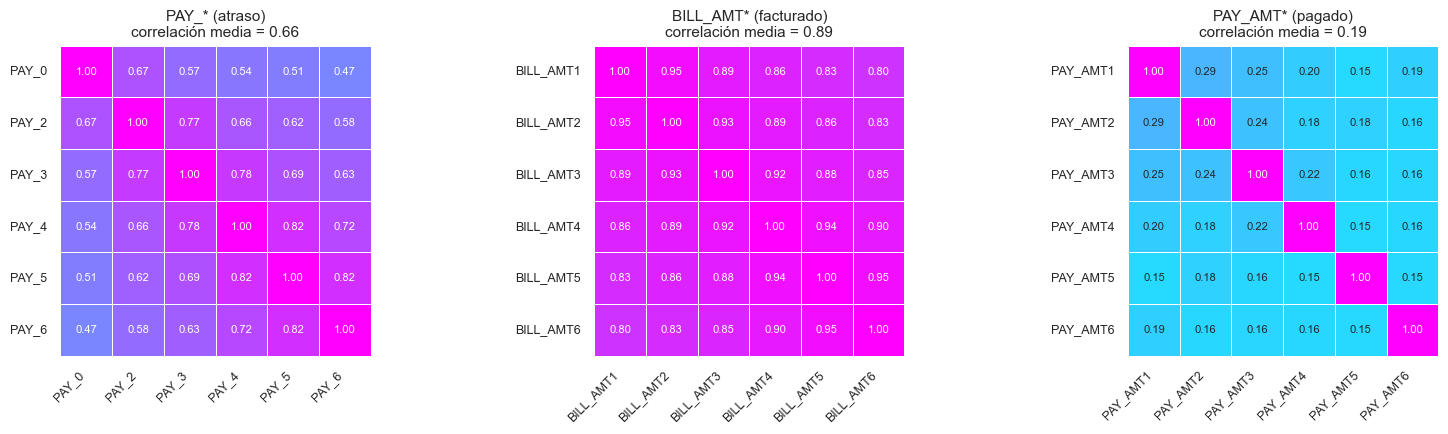

In [17]:
bloques = {
    "PAY_* (atraso)": ORDINALES,
    "BILL_AMT* (facturado)": [f"BILL_AMT{i}" for i in range(1, 7)],
    "PAY_AMT* (pagado)": [f"PAY_AMT{i}" for i in range(1, 7)],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (nombre, cols) in zip(axes, bloques.items()):
    m = df[cols].corr()
    sns.heatmap(m, annot=True, fmt=".2f", cmap="cool", vmin=0, vmax=1,
                square=True, linewidths=0.5, cbar=False, ax=ax,
                annot_kws={"fontsize": 8})
    fuera_diag = m.values[~np.eye(len(cols), dtype=bool)]
    ax.set_title(f"{nombre}\ncorrelación media = {fuera_diag.mean():.2f}", fontsize=11)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

Los tres bloques se comportan de manera muy distinta:

- **`BILL_AMT*`: correlación media de 0.89**, llegando a $0.95$ entre meses consecutivos. Es lo esperable, porque son
  el saldo de la tarjeta de un mismo cliente en seis meses seguidos: si alguien debe NT\$50.000 en septiembre, lo más
  probable es que debiera algo parecido en agosto. **No son seis variables, es una sola medida seis veces.**
- **`PAY_*`: correlación media de 0.66.** Alta, pero con más información propia: el atraso cambia mes a mes.
- **`PAY_AMT*`: correlación media de 0.19.** Prácticamente independientes entre sí, porque lo que uno paga cada mes
  es bastante errático.

Esta redundancia tiene consecuencias al modelar: hay **multicolinealidad severa** en el bloque de saldos. Los modelos
lineales sin regularizar se vuelven inestables, y cualquier método que asuma independencia entre features va a
contar seis veces la misma evidencia. Conviene usar modelos regularizados o basados en árboles, o bien reducir el
bloque (por ejemplo, quedándose con el último saldo y la variación respecto del mes anterior).

---
## Observaciones clave

1. **30.000 clientes, 23 features, sin valores nulos.** Todos los montos en dólares taiwaneses (NT\$).
2. **Hay tres tipos de variables** que conviene tratar distinto: 3 categóricas nominales, 6 categóricas ordinales
   (`PAY_*`) y 14 numéricas continuas. `pandas` las lee todas como números, pero no lo son.
3. **Desbalanceado**: $22.1\%$ de default. El accuracy es engañoso.
4. **`PAY_0` es el predictor dominante**: la tasa pasa de $12.8\%$ a $69.1\%$ entre estar al día y arrastrar dos
   meses de atraso.
5. **Esa relación es un escalón, no una recta.** Los valores $-2$, $-1$ y $0$ tienen prácticamente el mismo riesgo.
   Tratar a las `PAY_*` como numéricas perjudica a los modelos lineales; conviene codificarlas como categorías.
6. **Hay categorías no documentadas** en `EDUCATION` (0, 5, 6) y `MARRIAGE` (0), que suman poco más del $1\%$ y
   funcionan como datos ausentes enmascarados.
7. **Multicolinealidad severa en `BILL_AMT*`** (correlación media $0.89$). Los saldos mensuales son redundantes
   entre sí.
8. **Las escalas son muy dispares** y los montos están fuertemente sesgados: hace falta escalar.

---
## Baseline para comparar

Antes de entrenar modelos complejos, conviene definir un **baseline** simple contra el cual medir cualquier mejora.
Vamos a construir dos.

El primero es el piso absoluto: predecir siempre la clase mayoritaria, sin mirar ningún dato.

El segundo aprovecha el hallazgo principal del EDA. Como `PAY_0` es de lejos el predictor más fuerte y toma pocos
valores distintos, podemos armar una **tabla de referencia**: para cada nivel de atraso, la tasa de default observada
en el conjunto de entrenamiento. Predecir con esa tabla no requiere ningún modelo, solo un `groupby`.

Primero aplicamos la limpieza que identificamos más arriba.

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

datos = df.drop(columns=["ID", "situacion"]).copy()

# Categorías no documentadas -> "otros"
datos["EDUCATION"] = datos["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
datos["MARRIAGE"] = datos["MARRIAGE"].replace({0: 3})

# Los atrasos de 4 meses o más son muy poco frecuentes: los agrupamos
for col in ORDINALES:
    datos[col] = datos[col].clip(-1, 4)

X = datos.drop(columns=TARGET)
y = datos[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train: {len(y_train)} | Test: {len(y_test)}")

Train: 21000 | Test: 9000


In [19]:
# --- Baseline 1: siempre la clase mayoritaria
dummy = DummyClassifier(strategy="prior").fit(X_train, y_train)
probs_dummy = dummy.predict_proba(X_test)[:, 1]

# --- Baseline 2: tabla de referencia según PAY_0
tasa_por_atraso = y_train.groupby(X_train["PAY_0"]).mean()
probs_tabla = X_test["PAY_0"].map(tasa_por_atraso).fillna(y_train.mean()).to_numpy()

tasa_por_atraso.round(3)

PAY_0
-1    0.155
 0    0.126
 1    0.342
 2    0.695
 3    0.765
 4    0.611
Name: default.payment.next.month, dtype: float64

In [20]:
def evaluar(nombre, probs):
    pred = (probs >= 0.5).astype(int)  # noqa: PLR2004
    return {
        "modelo": nombre,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced acc.": balanced_accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "AUC": roc_auc_score(y_test, probs),
        "Brier": brier_score_loss(y_test, probs),
    }


pd.DataFrame([
    evaluar("Clase mayoritaria", probs_dummy),
    evaluar("Tabla por PAY_0", probs_tabla),
]).set_index("modelo").round(4)

,Accuracy,Balanced acc.,F1,AUC,Brier
modelo,,,,,
Clase mayoritaria,0.7788,0.5000,0.0000,0.5000,0.1723
Tabla por PAY_0,0.8182,0.6413,0.4409,0.7034,0.1429


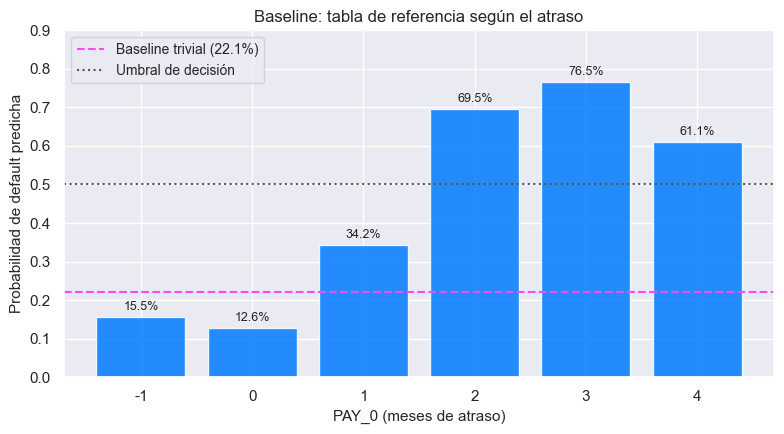

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(tasa_por_atraso.index.astype(str), tasa_por_atraso.values,
              color="#007aff", alpha=0.85)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in tasa_por_atraso.values],
             padding=3, fontsize=9)
ax.axhline(y_train.mean(), color="#ff48fd", linestyle="--", lw=1.5,
           label="Baseline trivial (22.1%)")
ax.axhline(0.5, color="#555555", linestyle=":", lw=1.5, label="Umbral de decisión")

ax.set_xlabel("PAY_0 (meses de atraso)", fontsize=11)
ax.set_ylabel("Probabilidad de default predicha", fontsize=11)
ax.set_title("Baseline: tabla de referencia según el atraso", fontsize=12)
ax.set_ylim(0, 0.9)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

El resultado es contundente. Con **una sola variable y un `groupby`**, sin entrenar ningún modelo, el baseline por
tabla consigue:

- **AUC de 0.703**, contra el $0.5$ del baseline trivial.
- **Accuracy de 0.818**, que además supera al $0.779$ de predecir siempre "al día".
- **Brier de 0.143**, bastante por debajo del $0.172$ del baseline trivial.

Ese es el número a superar. Cualquier modelo que entrenemos sobre las 23 features tiene que mejorar claramente estas
métricas para justificar su complejidad: si un Random Forest con 300 árboles termina en un AUC de $0.71$, en la
práctica no aportó nada sobre mirar una sola columna.

Notar también que el baseline **solo puede predecir seis valores distintos** de probabilidad, uno por nivel de
atraso. Es su techo: no distingue entre dos clientes con el mismo atraso pero límites de crédito o historiales de
pago muy distintos. Ahí es donde un modelo debería aportar valor.

---

El dataset en [Kaggle](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset).